## Plotting of unstructured Gird SCHISM output
### this is a small example on how to plot the outputs produced via SCHISM hydro

In [126]:
# Load Libraries
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import numpy as np
from schism_edito import *  

In [127]:
# load the setup and access to the outputfile sform unstructured grid
s=schism_setup()
s.ds=schism_outputs_by_variable(ncdir='./')

## Plot the Domain

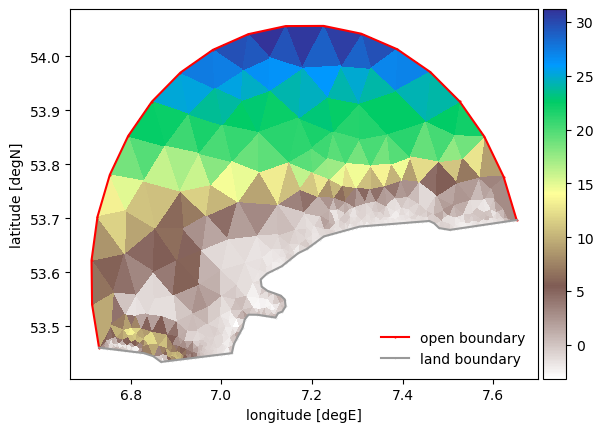

In [167]:
# Plot the Domain
ph,ch,ax=s.plotAtnodes(s.depths,cmap=plt.cm.terrain_r)
s.plot_domain_boundaries(latlon=True,append=True)
ch.set_label('depth [m]')


## Select lon and lat  coordinate  for a time series plot

In [129]:
# time series  - select location for time series plot
lon=7.2
lat=53.9

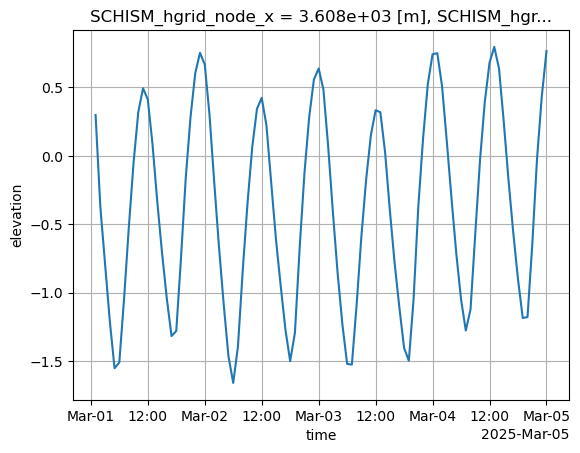

In [130]:
# load time seires
s.init_node_tree(latlon=True)                                     # initialize the nearest neighbour look up table
dd,nn=s.node_tree_latlon.query((lon,lat))                         # select nearest neighbour grid point
time_series=s.ds.get('elevation').sel(nSCHISM_hgrid_node=nn)      # fetch elevation at nearest node
time_series.plot()                                             # plot it via xarray wrap
plt.grid()

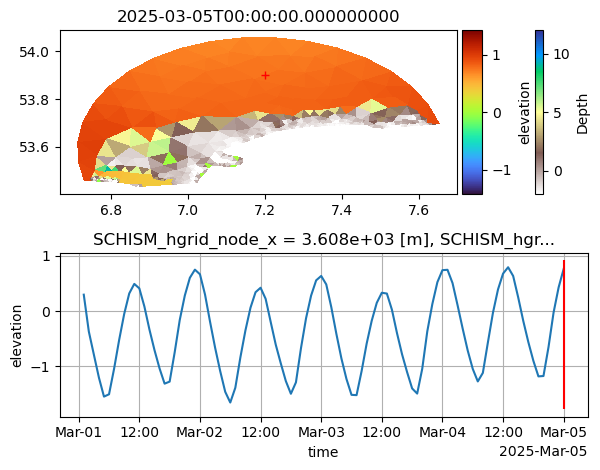

In [168]:
# Animate a variable

varname='elevation'                          # still fixed
elev=s.ds.get(varname)                       # get elevation field
time_vector=s.ds.ds['out2d']['time'].values  # load time variable

dry=s.ds.ds['out2d']['dryFlagNode'].values  # extract which areas are fallen dry

 # auto scale the plot range
vmax=np.quantile(np.abs(elev.values.flatten()),0.95)
vmin = 0 if elev.min().values > 0 else -vmax

for i in range(len(time_vector)):
    plt.subplot(2,1,1)
    ph,ch,ax=s.plotAtnodes(s.depths,plt.cm.terrain_r)    # plot the bathymetry
    ph2,ch2,ax2=s.plotAtnodes(elev[i,:],cmap=plt.cm.turbo,mask=dry[i,:][s.nvplt].mean(axis=1)) # where it is not fallen try elevation is plotted on top of bathymety
    ch.remove()
    #cb1 = plt.colorbar(ph, ax=ax2, orientation='horizontal', fraction=0.046, pad=0.1, label='Depth')
    ph.set_clim((-2,12))
    cb1 = plt.colorbar(ph, ax=ax2, orientation='vertical', fraction=0.1, pad=0.1, label='Depth')
    ax2.plot(lon,lat,'r+')                # plot time series location
    ph2.set_clim((vmin,vmax))
    ch2.set_label(varname)
    plt.title(time_vector[i])
    clear_output(wait=True)
    plt.subplot(2,1,2)
    ph2=time_series.plot()     
    ax2 = plt.gca()  # get current axes of the time series plot
    ymin, ymax = ax2.get_ylim()  # get dynamic y-limits
    plt.grid()
    plt.tight_layout()    
    plt.vlines(time_vector[i],ymin=ymin,ymax=ymax,color='r')
    plt.show()
    time.sleep(0.1)
